# Generic geographically weighted models

`spatialml` implements generic structures for geographically weighted modelling useful for flexible prototyping of various types of local models. On top, it provides implementation of a subset of specific models for regression and classification tasks.

## Common principle

The principle applied here is the same as in standard geographically weighted regression:

- Each observation in the (spatial) dataset has a local model.
- Each local model is fitted on a neighbourhood around its focal observation defined by a set bandwidth.
- Each local model uses sample weighting derived from the distance to the focal point and a set kernel function.

## Building geographically weighted Ridge regression

Explore the principle by implementing geographically weighted Ridge regression.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from geodatasets import get_path

from spatialml.base import BaseRegressor

Load some data. In this example, you can predict the number of suicides based on other population data in the [Guerry](https://geodacenter.github.io/data-and-lab//Guerry/) dataset.

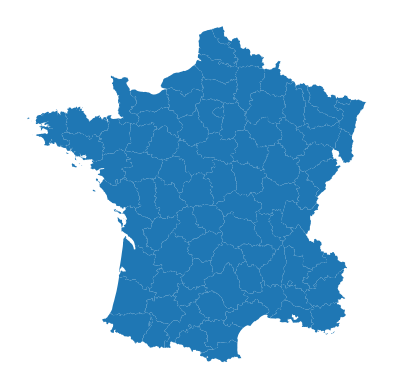

In [2]:
gdf = gpd.read_file(get_path("geoda.guerry"))
gdf.plot().set_axis_off()

Start with the model class that will be used as individual local models. In this case, `Ridge` regression.

In [3]:
from sklearn.linear_model import Ridge

With this, you can use `BaseRegressor` to build geographically weighted version of `Ridge`.

In [4]:
gwr = BaseRegressor(
    model=Ridge,
    bandwidth=25,
    fixed=False,
    kernel="bisquare",
    include_focal=True,
)
gwr

,model,<class 'sklea..._ridge.Ridge'>
,bandwidth,25
,fixed,False
,kernel,'bisquare'
,include_focal,True
,graph,None
,n_jobs,-1
,fit_global_model,True
,strict,False
,keep_models,False
,temp_folder,None


The model specification above contains the model class, the bandwidth size and type (adaptive bandwidth with 25 nearest neighbors) and a deifinition of the kernel to be used for sample weights. Given we are dealing with a linear model, we can also include the focal observation in the training, while still using it for evaluation later.

Fitting the model works as you know it from scikit-learn itself. However, we need to specify `geometry` representing location of observations. Alternatively, you could pass directly a `libpysal.graph.Graph` object capturing spatial neighborhoods and weights directly to ``__init__``.

In [5]:
gwr.fit(
    X=gdf[["Crm_prp", "Litercy", "Donatns", "Lottery"]],
    y=gdf["Suicids"],
    geometry=gdf.centroid,
)

,model,<class 'sklea..._ridge.Ridge'>
,bandwidth,25
,fixed,False
,kernel,'bisquare'
,include_focal,True
,graph,None
,n_jobs,-1
,fit_global_model,True
,strict,False
,keep_models,False
,temp_folder,None


The basic model contains some information that is common to any generic regressive model.

The first is prediction on focal geometries using the local model built around each (individually). 

In [6]:
gwr.pred_

0     60807.269716
1     14283.592391
2     61896.662372
3     26229.975118
4     15534.024239
          ...     
80    42596.030159
81    19913.727403
82    29123.881589
83    25874.639607
84    19152.819736
Length: 85, dtype: float64

Similarly, you can get residuals based on this prediction.

In [7]:
gwr.resid_

0    -25768.269716
1     -1452.592391
2     52224.337628
3    -11991.975118
4       636.975761
          ...     
80    25366.969841
81     1937.272597
82     4373.118411
83     7154.360393
84    -6363.819736
Length: 85, dtype: float64

Both of which can be plotted and compared to the original `y`.

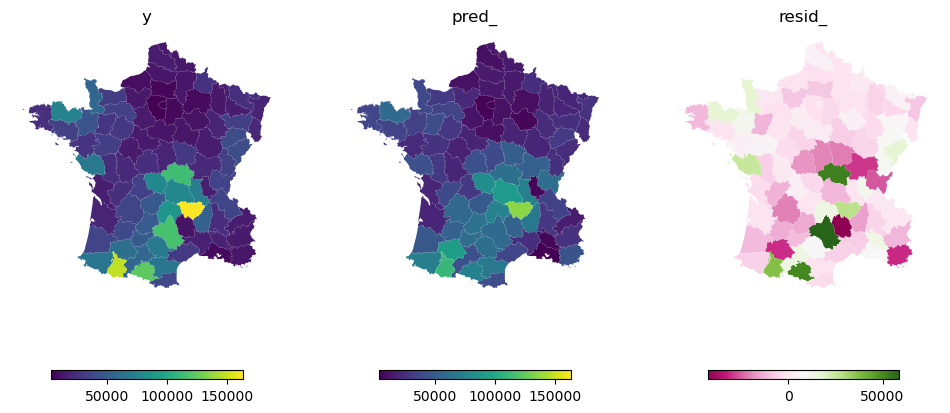

In [8]:
f, axs = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

top = gdf["Suicids"].max()
low = gdf["Suicids"].min()
leg = {"orientation": "horizontal", "shrink": 0.7}

gdf.plot("Suicids", ax=axs[0], legend=True, legend_kwds=leg)
gdf.plot(gwr.pred_, ax=axs[1], vmin=low, vmax=top, legend=True, legend_kwds=leg)
gdf.plot(gwr.resid_, ax=axs[2], cmap="PiYG", legend=True, legend_kwds=leg)

for ax in axs.flat:
    ax.set_axis_off()

axs[0].set_title("y")
axs[1].set_title("pred_")
axs[2].set_title("resid_");

With regression models, you can further retrieve local $R^2$.

In [9]:
gwr.local_r2_

0     0.666984
1     0.587867
2     0.638561
3     0.686175
4     0.719083
        ...   
80    0.506187
81    0.594817
82    0.671307
83    0.165854
84    0.397928
Length: 85, dtype: float64

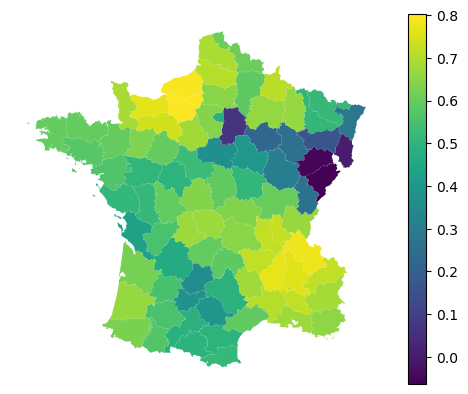

In [10]:
gdf.plot(gwr.local_r2_, legend=True).set_axis_off()

## Implemented models

While this captures the generic case and can be extrapolated to many other predictive models, it has some limitations. Notably, it is unable to extract information linked to specificities of the selected model. In case of Ridge regression, we might be interested in fitted coefficients, in case of non-linear models in feature importance and so on. You can achieve this by subclassing `BaseRegressor` and providing customized `fit` method. See the implementation of existing models for illustration.

Consult the rest of the user guide to get an overview of implemented models and other functionality.